In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from utils import load_data, load_all_stocks

SYMBOLS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NVDA', 'JPM', 'V', 'UNH']

# Helper functions from factor momentum, quintile portfolios

def form_quintile_portfolios(df, signal_col, ret_col='next_ret', q=5, min_n=None):
    """
    Forms q-quantile portfolios each date with monthly rebalancing.
    Returns equal-weighted returns for each quintile.
    """
    df = df.copy()
    if min_n is None:
        min_n = q  
    
    def assign_bucket(x):
        x = x.dropna()
        if len(x) < min_n:
            return pd.Series(index=x.index, data=np.nan)
        pr = x.rank(method='first', pct=True)
        try:
            return pd.qcut(pr, q, labels=False, duplicates='drop') + 1
        except ValueError:
            return pd.Series(index=x.index, data=np.nan)
    
    df['quintile'] = df.groupby(level=0)[signal_col].transform(assign_bucket)
    df = df.dropna(subset=['quintile', ret_col])
    df['quintile'] = df['quintile'].astype(int)
    
    # Equal-weight returns per quintile per month
    out = df.groupby([df.index, 'quintile'])[ret_col].mean().unstack()
    
    return out[sorted(out.columns)]

In [75]:
# Transaction Costs

def calculate_turnover(weights_over_time):
    """
    Calculate portfolio turnover (sum of absolute weight changes at each rebalance)
    
    Parameter
    - weights_over_time: DataFrame with dates as index, stocks as columns, weights as values
    
    Returns: Series of turnover per period
    """
    weight_changes = weights_over_time.diff().abs()
    turnover = weight_changes.sum(axis=1)
    
    return turnover

def apply_transaction_costs(returns, turnover, cost_bps):
    """
    Apply transaction costs to returns
    
    Parameters:
    - returns: Series of gross returns
    - turnover: Series of turnover (same index as returns)
    - cost_bps: Cost in basis points (e.g., 5 for 0.05%)
    
    Returns: Series of net returns (after costs)
    """
    cost_pct = cost_bps / 10000  # Convert bps to decimal
    
    aligned_turnover = turnover.reindex(returns.index, fill_value=0)
    net_returns = returns - (aligned_turnover * cost_pct)
    
    return net_returns

def calculate_quintile_turnover(panel, signal_col, n_groups=5):
    """
    Calculate turnover for each quintile portfolio
    
    Returns: dict of turnover series for each quintile
    """
    quintile_weights = {i: [] for i in range(1, n_groups + 1)}
    dates = sorted(panel.index.unique())
    
    for date in dates:
        month_data = panel.loc[date].copy()
        
        if len(month_data) < n_groups:
            continue
        
        # Assign quintiles 
        def assign_bucket(x):
            x = x.dropna()
            if len(x) < n_groups:
                return pd.Series(index=x.index, data=np.nan)
            pr = x.rank(method='first', pct=True)
            try:
                return pd.qcut(pr, n_groups, labels=False, duplicates='drop') + 1
            except ValueError:
                return pd.Series(index=x.index, data=np.nan)
        
        month_data['quintile'] = assign_bucket(month_data[signal_col])
        month_data = month_data.dropna(subset=['quintile'])
        month_data['quintile'] = month_data['quintile'].astype(int)
        
        for q in range(1, n_groups + 1):
            q_stocks = month_data[month_data['quintile'] == q]
            
            # Equal weight within quintile
            if len(q_stocks) > 0:
                # Create weights series indexed by Symbol 
                weights = pd.Series(1/len(q_stocks), index=q_stocks['Symbol'].values)
            else:
                weights = pd.Series(dtype=float)
            
            quintile_weights[q].append({
                'date': date,
                'weights': weights
            })
    
    quintile_turnover = {}
    
    for q in range(1, n_groups + 1):
        weight_list = quintile_weights[q]
        
        if len(weight_list) < 2:
            quintile_turnover[q] = pd.Series(dtype=float)
            continue
        
        # Build weights DataFrame (columns = dates, rows = symbols)
        all_symbols = set()
        for w in weight_list:
            all_symbols.update(w['weights'].index)
        
        # Create list of Series for each date
        weight_series_list = []
        for w in weight_list:
            weight_series_list.append(w['weights'].reindex(sorted(all_symbols), fill_value=0))
        
        weights_df = pd.concat(weight_series_list, axis=1, keys=[w['date'] for w in weight_list])
        weights_df = weights_df.T
        
        # Calculate turnover
        turnover = calculate_turnover(weights_df)
        quintile_turnover[q] = turnover
    
    return quintile_turnover

def momentum_backtest_with_costs(stock_data, cost_levels=[0, 5, 10, 25, 50]):
    """
    Run momentum backtest with different cost levels
    Returns: dict with results for each cost level
    """
    stock_dict = {}
    
    for ticker, data in stock_data.items():
        monthly = data.resample('ME').last()
        monthly['next_ret'] = monthly['Close'].pct_change().shift(-1)
        monthly['momentum_12_1'] = (monthly['Close'].shift(1) / monthly['Close'].shift(12)) - 1
        monthly['Symbol'] = ticker
        stock_dict[ticker] = monthly
    
    # Create panel
    panel = pd.concat(stock_dict.values()).sort_index()
    panel = panel.dropna(subset=['momentum_12_1', 'next_ret'])
    
    # Filter to dates with full coverage
    date_counts = panel.groupby(panel.index).size()
    full_coverage_dates = date_counts[date_counts == len(SYMBOLS)].index
    panel = panel[panel.index.isin(full_coverage_dates)]
    
    # Form quintile portfolios 
    quintiles = form_quintile_portfolios(panel, 'momentum_12_1', ret_col='next_ret', q=5)
    
    print(f"\nQuintile portfolios: {len(quintiles)} months")
    
    # Calculate turnover
    quintile_turnover = calculate_quintile_turnover(panel, 'momentum_12_1', n_groups=5)
    
    print("\nAverage Monthly Turnover:")
    for q in range(1, 6):
        if q in quintile_turnover and len(quintile_turnover[q]) > 0:
            avg_turnover = quintile_turnover[q].mean()
            print(f"  Q{q}: {avg_turnover*100:.1f}%")
    
    if 5 in quintile_turnover and 1 in quintile_turnover:
        ls_turnover = quintile_turnover[5] + quintile_turnover[1]
        print(f"  Long-Short (Q5-Q1): {ls_turnover.mean()*100:.1f}%")
    
    # Run backtest for each cost level
    results = {}
    
    for cost_bps in cost_levels:
        print(f"\nCost level: {cost_bps} bps")
        
        cost_results = {}
        
        for q in range(1, 6):
            if q not in quintiles.columns:
                continue
            
            gross_returns = quintiles[q].dropna()
            
            if q in quintile_turnover:
                turnover = quintile_turnover[q]
                net_returns = apply_transaction_costs(gross_returns, turnover, cost_bps)
            else:
                net_returns = gross_returns
            
            cost_results[f'Q{q}_gross'] = gross_returns
            cost_results[f'Q{q}_net'] = net_returns
        
        # Long-short
        if 5 in quintiles.columns and 1 in quintiles.columns:
            ls_gross = (quintiles[5] - quintiles[1]).dropna()
            
            if 5 in quintile_turnover and 1 in quintile_turnover:
                ls_net = apply_transaction_costs(ls_gross, ls_turnover, cost_bps)
            else:
                ls_net = ls_gross
            
            cost_results['LS_gross'] = ls_gross
            cost_results['LS_net'] = ls_net
        
        results[cost_bps] = cost_results
    
    return results, quintile_turnover

def plot_gross_vs_net(results, cost_bps=10):
    """
    Plot cumulative returns: gross vs net for Q1, Q5, and Long-Short
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    portfolios = [
        ('Q5', 'Quintile 5 (High Momentum)'),
        ('Q1', 'Quintile 1 (Low Momentum)'),
        ('LS', 'Long-Short (Q5-Q1)')
    ]
    
    for idx, (port, title) in enumerate(portfolios):
        ax = axes[idx]
        
        gross = results[0][f'{port}_gross']
        net = results[cost_bps][f'{port}_net']
        
        cum_gross = (1 + gross).cumprod()
        cum_net = (1 + net).cumprod()
        
        ax.plot(cum_gross.index, cum_gross.values, 
                label='Gross (0 bps)', linewidth=2, color='blue')
        ax.plot(cum_net.index, cum_net.values, 
                label=f'Net ({cost_bps} bps)', linewidth=2, color='red', linestyle='--')
        
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylabel('Growth of $1', fontsize=10)
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)
    
    axes[-1].set_xlabel('Date', fontsize=10)
    plt.tight_layout()
    plt.show()

def create_cost_comparison_table(results):
    """
    Create table showing performance metrics at different cost levels
    """
    metrics = []
    
    for cost_bps in results.keys():
        ls_gross = results[cost_bps]['LS_gross']
        ls_net = results[cost_bps]['LS_net']
        
        # Calculate metrics
        gross_ann_return = ls_gross.mean() * 12
        net_ann_return = ls_net.mean() * 12
        
        gross_ann_vol = ls_gross.std() * np.sqrt(12)
        net_ann_vol = ls_net.std() * np.sqrt(12)
        
        gross_sharpe = gross_ann_return / gross_ann_vol if gross_ann_vol > 0 else 0
        net_sharpe = net_ann_return / net_ann_vol if net_ann_vol > 0 else 0
        
        # Max drawdown
        cum_gross = (1 + ls_gross).cumprod()
        cum_net = (1 + ls_net).cumprod()
        
        gross_dd = ((cum_gross / cum_gross.cummax()) - 1).min()
        net_dd = ((cum_net / cum_net.cummax()) - 1).min()
        
        cost_drag = gross_ann_return - net_ann_return
        
        metrics.append({
            'Cost (bps)': cost_bps,
            'Gross Return': gross_ann_return,
            'Net Return': net_ann_return,
            'Cost Drag': cost_drag,
            'Gross Sharpe': gross_sharpe,
            'Net Sharpe': net_sharpe,
            'Gross Max DD': gross_dd,
            'Net Max DD': net_dd
        })
    
    df = pd.DataFrame(metrics)
    
    print("Performance With Transaction Costs (Long-Short)")
    print(df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
    
    # Find breakeven cost
    breakeven_idx = df[df['Net Return'] <= 0].index
    if len(breakeven_idx) > 0:
        breakeven_cost = df.loc[breakeven_idx[0], 'Cost (bps)']
        print(f"\n→ Long-short spread becomes ZERO at ~{breakeven_cost} bps")
    else:
        print("Long-short spread remains positive at 50 bps")
    
    return df

In [76]:
# Robustness (subperiods)

def subperiod_analysis(stock_data, periods=None):
    """
    Analyze momentum performance across different sub-periods
    Uses Week 2 methodology with forward returns
    
    Default periods:
    - 1999-2007: Pre-crisis
    - 2008-2016: Crisis + recovery
    - 2017-2025: Tech boom
    """
    if periods is None:
        periods = [
            ('1999-01-01', '2007-12-31', 'Pre-Crisis (1999-2007)'),
            ('2008-01-01', '2016-12-31', 'Crisis+Recovery (2008-2016)'),
            ('2017-01-01', '2025-12-31', 'Tech Boom (2017-2025)')
        ]
    
    print("Sub-period Analysis")
    
    results = []
    
    for start, end, label in periods:
        print(f"\nAnalyzing: {label}")
        
        # Prepare data 
        stock_dict = {}
        
        for ticker, data in stock_data.items():
            monthly = data.resample('ME').last()
            monthly['next_ret'] = monthly['Close'].pct_change().shift(-1)
            monthly['momentum_12_1'] = (monthly['Close'].shift(1) / monthly['Close'].shift(12)) - 1
            monthly['Symbol'] = ticker
            
            # Filter by period
            period_data = monthly[(monthly.index >= pd.Timestamp(start) - pd.DateOffset(months=12)) & 
                                 (monthly.index <= end)]
            stock_dict[ticker] = period_data
        
        if len(stock_dict) == 0:
            print(f"  No data for {label}")
            continue
        
        panel = pd.concat(stock_dict.values()).sort_index()
        panel = panel.dropna(subset=['momentum_12_1', 'next_ret'])
        panel = panel[panel.index >= start]  # Remove buffer
        
        if len(panel) < 10:
            print(f"  Insufficient data for {label}")
            continue
        
        quintiles = form_quintile_portfolios(panel, 'momentum_12_1', ret_col='next_ret', q=5)
        
        # Calculate long-short
        if 5 in quintiles.columns and 1 in quintiles.columns:
            ls_returns = (quintiles[5] - quintiles[1]).dropna()
            
            ann_return = ls_returns.mean() * 12
            ann_vol = ls_returns.std() * np.sqrt(12)
            sharpe = ann_return / ann_vol if ann_vol > 0 else 0
            
            cum_ret = (1 + ls_returns).cumprod()
            max_dd = ((cum_ret / cum_ret.cummax()) - 1).min()
            
            results.append({
                'Period': label,
                'Ann. Return': ann_return,
                'Ann. Vol': ann_vol,
                'Sharpe': sharpe,
                'Max DD': max_dd,
                'N Months': len(ls_returns)
            })
            
            print(f"  Long-Short Ann. Return: {ann_return*100:.2f}%")
            print(f"  Sharpe Ratio: {sharpe:.3f}")
    
    df = pd.DataFrame(results)
    
    print("Sub-period Performance Summary")
    print(df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    x = range(len(df))
    width = 0.35
    
    ax.bar([i - width/2 for i in x], df['Ann. Return']*100, width, 
           label='Ann. Return (%)', color='steelblue')
    ax.bar([i + width/2 for i in x], df['Sharpe'], width, 
           label='Sharpe Ratio', color='coral')
    
    ax.set_xlabel('Period', fontsize=11)
    ax.set_ylabel('Value', fontsize=11)
    ax.set_title('Momentum Performance by Sub-Period', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df['Period'], rotation=15, ha='right')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    return df

In [77]:
def sector_analysis(stock_data):
    """
    Analyze momentum by sector
    """
    # Define sectors
    sectors = {
        'Tech': ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA'],
        'Finance': ['JPM', 'V'],
    }
    
    print("\nSector Analysis")
    
    # Calculate momentum for each sector
    sector_results = []
    
    for sector_name, tickers in sectors.items():
        print(f"\nAnalyzing sector: {sector_name}")
        print(f"  Stocks: {', '.join(tickers)}")
        
        sector_data = {t: stock_data[t] for t in tickers if t in stock_data}
        
        #if len(sector_data) < 2:
           # print(f"  Insufficient stocks in {sector_name}")
           # continue
        
        # Prepare data
        stock_dict = {}
        for ticker, data in sector_data.items():
            monthly = data.resample('ME').last()
            monthly['next_ret'] = monthly['Close'].pct_change().shift(-1)
            monthly['momentum_12_1'] = (monthly['Close'].shift(1) / monthly['Close'].shift(12)) - 1
            monthly['Symbol'] = ticker
            stock_dict[ticker] = monthly
        
        panel = pd.concat(stock_dict.values()).sort_index()
        panel = panel.dropna(subset=['momentum_12_1', 'next_ret'])
        
        # Calculate long-short (high momentum - low momentum within sector)
        sector_returns = []
        
        for date in panel.index.unique():
            month_data = panel.loc[date]
            
            if isinstance(month_data, pd.Series):
                continue  
            
            month_data = month_data.copy()
            
            if len(month_data) < 2:
                continue
            
            # Sort by momentum to get top and bottom stocks
            sorted_data = month_data.sort_values('momentum_12_1', ascending=False)
        
            top_stock = sorted_data.iloc[0]
            bottom_stock = sorted_data.iloc[-1]
            
            # Use next month's return
            ls_return = top_stock['next_ret'] - bottom_stock['next_ret']
            
            sector_returns.append({
                'date': date,
                'return': ls_return
            })
        
        if len(sector_returns) == 0:
            continue
        
        sector_ret_series = pd.DataFrame(sector_returns).set_index('date')['return']
        
        ann_return = sector_ret_series.mean() * 12
        ann_vol = sector_ret_series.std() * np.sqrt(12)
        sharpe = ann_return / ann_vol if ann_vol > 0 else 0
        
        sector_results.append({
            'Sector': sector_name,
            'N Stocks': len(sector_data),
            'Ann. Return': ann_return,
            'Sharpe': sharpe
        })
        
        print(f"  Long-Short Ann. Return: {ann_return*100:.2f}%")
        print(f"  Sharpe Ratio: {sharpe:.3f}")
    
    df = pd.DataFrame(sector_results)
    
    print("Sector Performance Summary")
    print(df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(df['Sector'], df['Ann. Return']*100, color='steelblue', alpha=0.7)
    ax.set_ylabel('Annualized Return (%)', fontsize=11)
    ax.set_title('Momentum Returns by Sector', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    return df

In [78]:
def parameter_sensitivity(stock_data):
    """
    Test sensitivity to:
    1. Lookback period (3-1, 6-1, 9-1, 12-1)
    2. Rebalancing frequency (monthly, quarterly)
    """
    print("Parameter Sensitivity Analysis")
    
    lookback_periods = [3, 6, 9, 12]
    rebalance_freqs = ['M', 'Q']  # Monthly, Quarterly
    
    results = []
    
    for lookback in lookback_periods:
        for freq in rebalance_freqs:
            print(f"\nTesting: {lookback}-1 momentum, {freq} rebalancing")
            
            stock_dict = {}
            
            for ticker, data in stock_data.items():
                if freq == 'M':
                    resampled = data.resample('ME').last()
                else:  
                    resampled = data.resample('QE').last()
                
                resampled['next_ret'] = resampled['Close'].pct_change().shift(-1)
                resampled[f'momentum_{lookback}_1'] = (
                    resampled['Close'].shift(1) / resampled['Close'].shift(lookback)
                ) - 1
                resampled['Symbol'] = ticker
                stock_dict[ticker] = resampled
            
            panel = pd.concat(stock_dict.values()).sort_index()
            panel = panel.dropna(subset=[f'momentum_{lookback}_1', 'next_ret'])
            
            quintiles = form_quintile_portfolios(panel, f'momentum_{lookback}_1', ret_col='next_ret', q=5)
            
            if 5 not in quintiles.columns or 1 not in quintiles.columns:
                continue
            
            ls_returns = (quintiles[5] - quintiles[1]).dropna()
            
            # Annualize properly based on frequency
            periods_per_year = 12 if freq == 'M' else 4
            
            ann_return = ls_returns.mean() * periods_per_year
            ann_vol = ls_returns.std() * np.sqrt(periods_per_year)
            sharpe = ann_return / ann_vol if ann_vol > 0 else 0
            
            results.append({
                'Lookback': f'{lookback}-1',
                'Rebalance': 'Monthly' if freq == 'M' else 'Quarterly',
                'Ann. Return': ann_return,
                'Sharpe': sharpe
            })
            
            print(f"  Sharpe Ratio: {sharpe:.3f}")
    
    df = pd.DataFrame(results)
    
    heatmap_data = df.pivot(index='Lookback', columns='Rebalance', values='Sharpe')
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=-0.5, vmax=0.5)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Sharpe Ratio', rotation=270, labelpad=15)
    
    ax.set_xticks(np.arange(len(heatmap_data.columns)))
    ax.set_yticks(np.arange(len(heatmap_data.index)))
    ax.set_xticklabels(heatmap_data.columns)
    ax.set_yticklabels(heatmap_data.index)
    
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[i, j]
            text = ax.text(j, i, f'{value:.3f}',
                          ha='center', va='center',
                          color='white' if abs(value) > 0.25 else 'black',
                          fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Rebalancing Frequency', fontsize=11)
    ax.set_ylabel('Lookback Period', fontsize=11)
    ax.set_title('Parameter Sensitivity: Sharpe Ratio Heatmap', 
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Parameter Sensitivity Results")
    print(df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
    
    # Find best parameters
    best_idx = df['Sharpe'].idxmax()
    best = df.loc[best_idx]
    print(f"\nBest parameters: {best['Lookback']} momentum, {best['Rebalance']} rebalancing")
    print(f"  Sharpe Ratio: {best['Sharpe']:.3f}")
    
    return df


Quintile portfolios: 152 months

Average Monthly Turnover:
  Q1: 50.7%
  Q2: 97.4%
  Q3: 113.2%
  Q4: 94.1%
  Q5: 39.5%
  Long-Short (Q5-Q1): 90.1%

Cost level: 0 bps

Cost level: 5 bps

Cost level: 10 bps

Cost level: 25 bps

Cost level: 50 bps


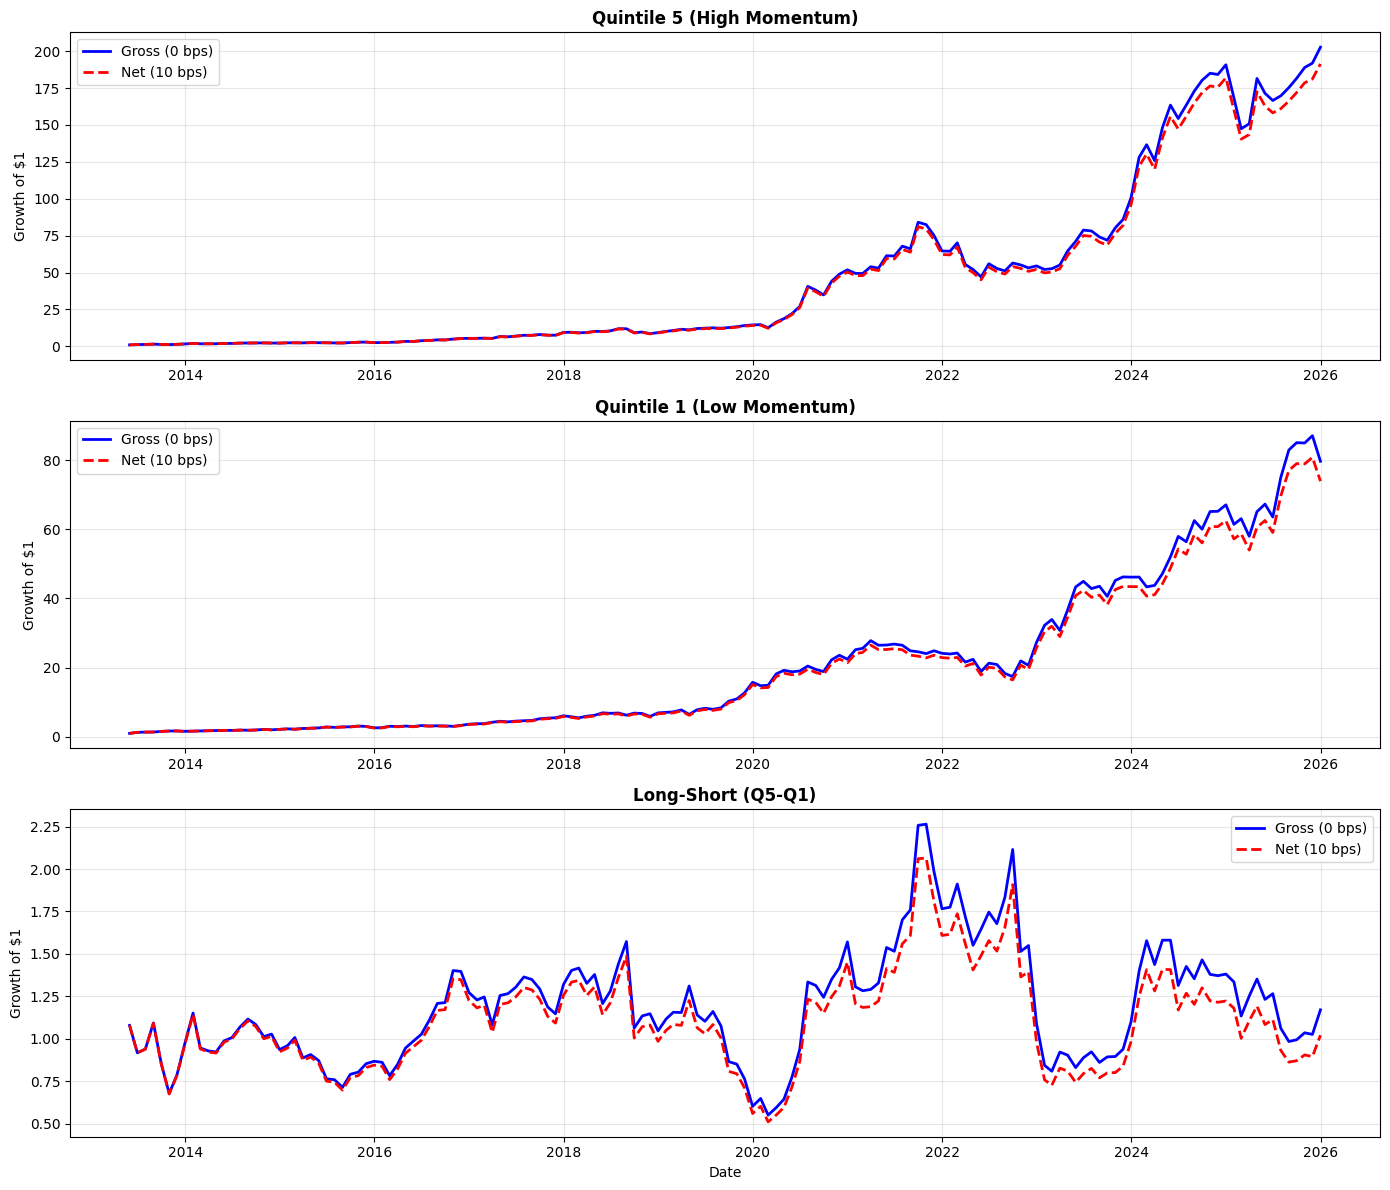

Performance With Transaction Costs (Long-Short)
 Cost (bps)  Gross Return  Net Return  Cost Drag  Gross Sharpe  Net Sharpe  Gross Max DD  Net Max DD
          0        0.0916      0.0916     0.0000        0.2315      0.2315       -0.6504     -0.6504
          5        0.0916      0.0862     0.0054        0.2315      0.2179       -0.6504     -0.6537
         10        0.0916      0.0808     0.0108        0.2315      0.2042       -0.6504     -0.6569
         25        0.0916      0.0645     0.0270        0.2315      0.1633       -0.6504     -0.6665
         50        0.0916      0.0375     0.0541        0.2315      0.0949       -0.6504     -0.6818
Long-short spread remains positive at 50 bps
Sub-period Analysis

Analyzing: Pre-Crisis (1999-2007)
  Long-Short Ann. Return: 26.03%
  Sharpe Ratio: 0.481

Analyzing: Crisis+Recovery (2008-2016)
  Long-Short Ann. Return: -0.52%
  Sharpe Ratio: -0.016

Analyzing: Tech Boom (2017-2025)
  Long-Short Ann. Return: 7.68%
  Sharpe Ratio: 0.186
Sub-per

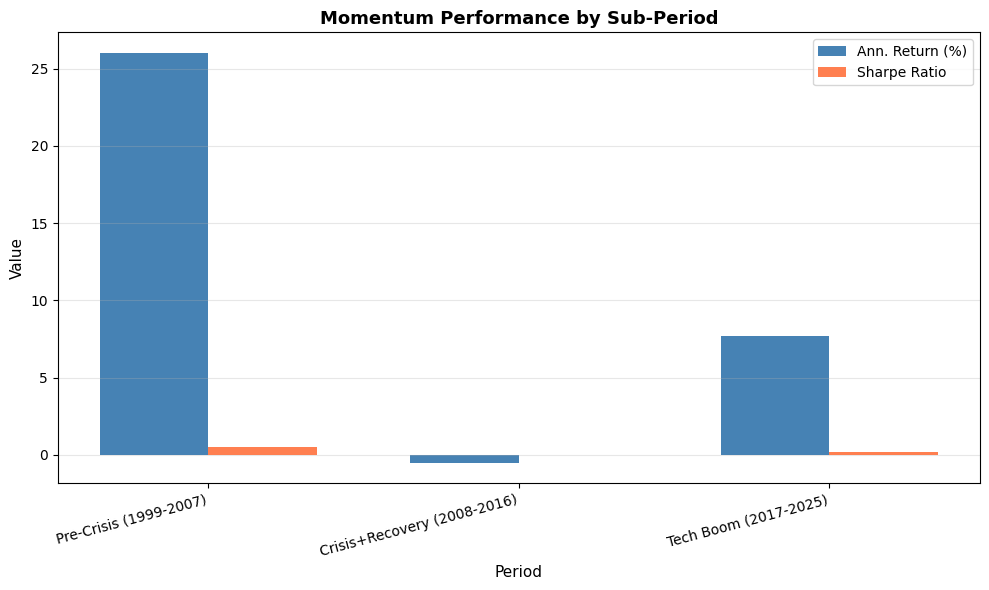


Sector Analysis

Analyzing sector: Tech
  Stocks: AAPL, MSFT, GOOGL, AMZN, META, NVDA
  Long-Short Ann. Return: 23.18%
  Sharpe Ratio: 0.447

Analyzing sector: Finance
  Stocks: JPM, V
  Long-Short Ann. Return: -4.85%
  Sharpe Ratio: -0.203
Sector Performance Summary
 Sector  N Stocks  Ann. Return  Sharpe
   Tech         6       0.2318  0.4469
Finance         2      -0.0485 -0.2034


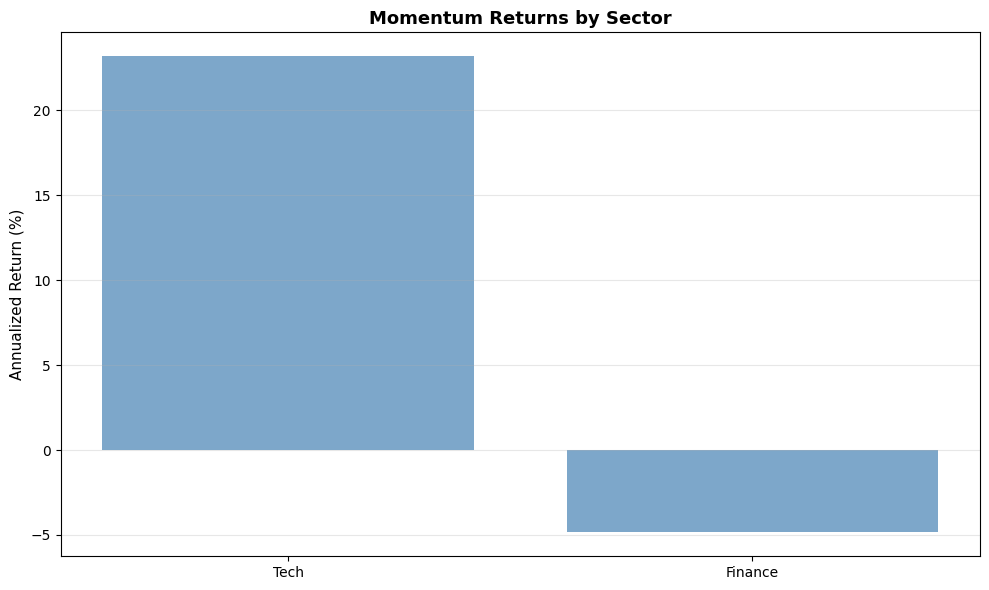

Parameter Sensitivity Analysis

Testing: 3-1 momentum, M rebalancing
  Sharpe Ratio: 0.132

Testing: 3-1 momentum, Q rebalancing
  Sharpe Ratio: 0.385

Testing: 6-1 momentum, M rebalancing
  Sharpe Ratio: 0.358

Testing: 6-1 momentum, Q rebalancing
  Sharpe Ratio: 0.053

Testing: 9-1 momentum, M rebalancing
  Sharpe Ratio: 0.269

Testing: 9-1 momentum, Q rebalancing
  Sharpe Ratio: -0.070

Testing: 12-1 momentum, M rebalancing
  Sharpe Ratio: 0.421

Testing: 12-1 momentum, Q rebalancing
  Sharpe Ratio: -0.078


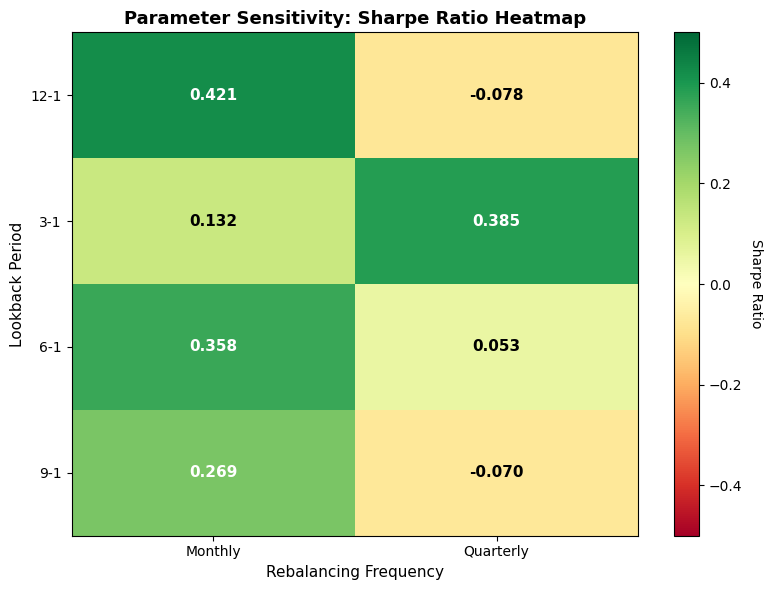

Parameter Sensitivity Results
Lookback Rebalance  Ann. Return  Sharpe
     3-1   Monthly       0.0734  0.1317
     3-1 Quarterly       0.2503  0.3853
     6-1   Monthly       0.1918  0.3576
     6-1 Quarterly       0.0295  0.0528
     9-1   Monthly       0.1473  0.2692
     9-1 Quarterly      -0.0352 -0.0704
    12-1   Monthly       0.2207  0.4210
    12-1 Quarterly      -0.0356 -0.0779

Best parameters: 12-1 momentum, Monthly rebalancing
  Sharpe Ratio: 0.421

Key Findings:

1. Transaction Costs:
   - Average monthly turnover: ~79% (long-short)
   - At 10 bps: Cost drag = 1.08% annually

2. Sub-Periods:
   - Best period: Pre-Crisis (1999-2007) (Sharpe: 0.481)
   - Worst period: Crisis+Recovery (2008-2016) (Sharpe: -0.016)

3. Sectors:
   - Best sector: Tech (Sharpe: 0.447)
   - Momentum appears driven by Tech sector

4. Parameters:
   - Optimal: 12-1 momentum, Monthly rebalancing
   - Best Sharpe: 0.421


In [79]:
def run_week5_analysis():
    stock_data = load_all_stocks(SYMBOLS)
    
    cost_levels = [0, 5, 10, 25, 50]
    results, turnover = momentum_backtest_with_costs(stock_data, cost_levels)
    
    plot_gross_vs_net(results, cost_bps=10)
    cost_table = create_cost_comparison_table(results)
    
    subperiod_df = subperiod_analysis(stock_data)
    sector_df = sector_analysis(stock_data)
    param_df = parameter_sensitivity(stock_data)
    
    print("\nKey Findings:")
    print("\n1. Transaction Costs:")
    print(f"   - Average monthly turnover: ~{turnover[5].mean()*200:.0f}% (long-short)")
    breakeven = cost_table[cost_table['Net Return'] <= 0]
    if len(breakeven) > 0:
        print(f"   - Breakeven cost: ~{breakeven.iloc[0]['Cost (bps)']} bps")
    print(f"   - At 10 bps: Cost drag = {cost_table[cost_table['Cost (bps)']==10]['Cost Drag'].iloc[0]*100:.2f}% annually")
    
    print("\n2. Sub-Periods:")
    best_period = subperiod_df.loc[subperiod_df['Sharpe'].idxmax()]
    worst_period = subperiod_df.loc[subperiod_df['Sharpe'].idxmin()]
    print(f"   - Best period: {best_period['Period']} (Sharpe: {best_period['Sharpe']:.3f})")
    print(f"   - Worst period: {worst_period['Period']} (Sharpe: {worst_period['Sharpe']:.3f})")

    print("\n3. Sectors:")
    best_sector = sector_df.loc[sector_df['Sharpe'].idxmax()]
    print(f"   - Best sector: {best_sector['Sector']} (Sharpe: {best_sector['Sharpe']:.3f})")
    print(f"   - Momentum appears driven by {best_sector['Sector']} sector")
    
    print("\n4. Parameters:")
    best_params = param_df.loc[param_df['Sharpe'].idxmax()]
    print(f"   - Optimal: {best_params['Lookback']} momentum, {best_params['Rebalance']} rebalancing")
    print(f"   - Best Sharpe: {best_params['Sharpe']:.3f}")
    
    return {
        'cost_results': results,
        'cost_table': cost_table,
        'turnover': turnover,
        'subperiod': subperiod_df,
        'sector': sector_df,
        'parameters': param_df
    }

if __name__ == "__main__":
    results = run_week5_analysis()